DATASET INFORMATION
Shape: (21263, 82)

Total Features: 81

Missing Values:
0


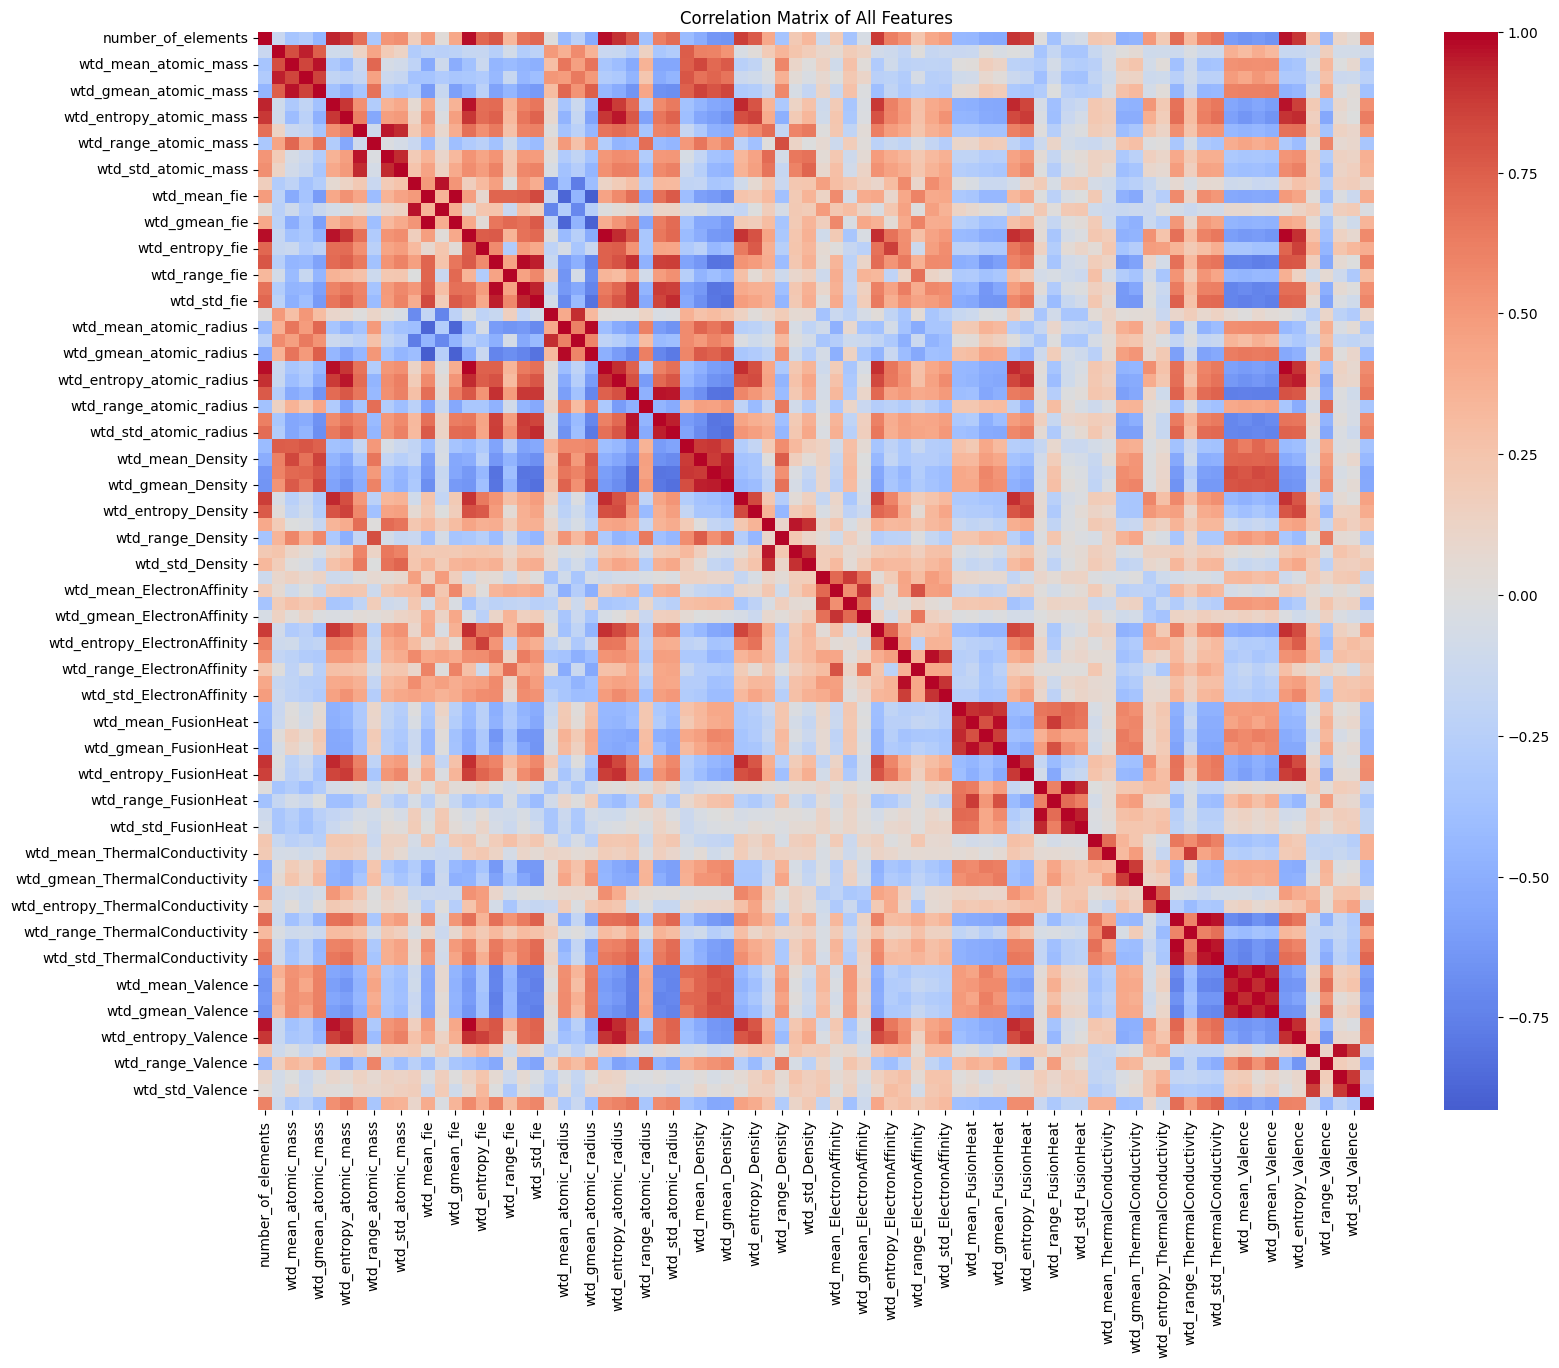



MODEL PERFORMANCE
MAE           : 13.2105
MSE           : 302.0075
RMSE          : 17.3784
R2 Score      : 0.7376
Adjusted R2   : 0.7325
MAPE          : 7.4769


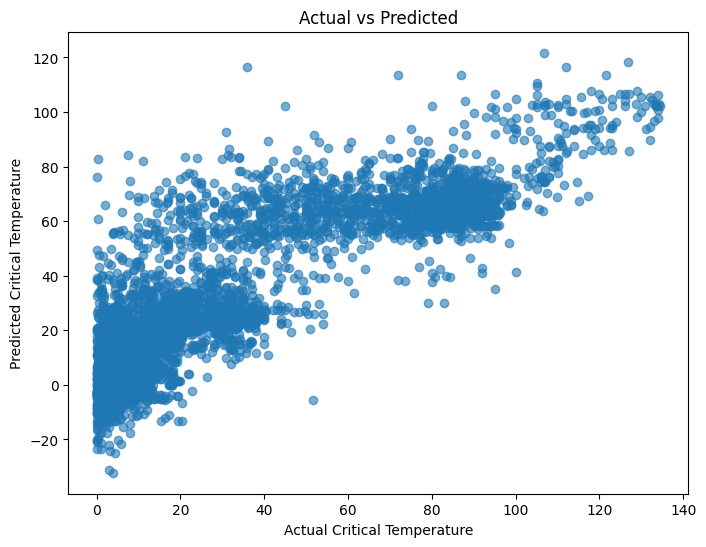

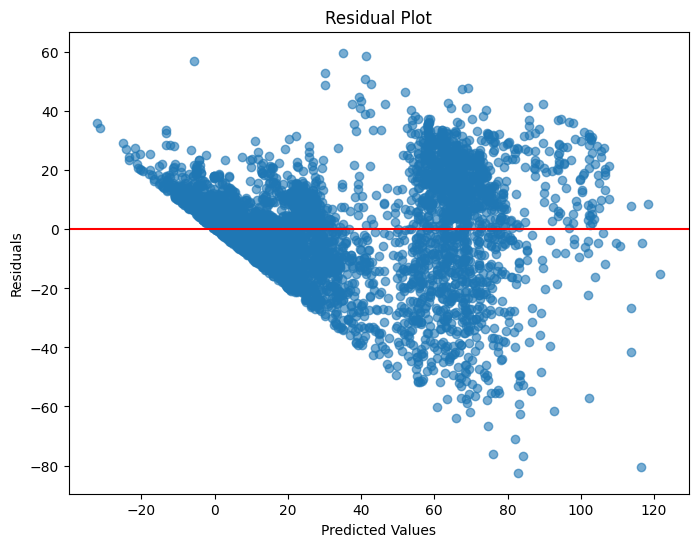



FEATURE IMPORTANCE
                            Feature  Coefficient  Absolute_Coefficient
24          wtd_gmean_atomic_radius   -89.139308             89.139308
22           wtd_mean_atomic_radius    83.170114             83.170114
15                      entropy_fie   -38.405674             38.405674
2              wtd_mean_atomic_mass   -32.204229             32.204229
74                wtd_gmean_Valence   -31.421406             31.421406
..                              ...          ...                   ...
8             wtd_range_atomic_mass     0.996289              0.996289
78                wtd_range_Valence    -0.623665              0.623665
38                wtd_range_Density    -0.521575              0.521575
23              gmean_atomic_radius    -0.457934              0.457934
66  wtd_entropy_ThermalConductivity     0.281668              0.281668

[81 rows x 3 columns]


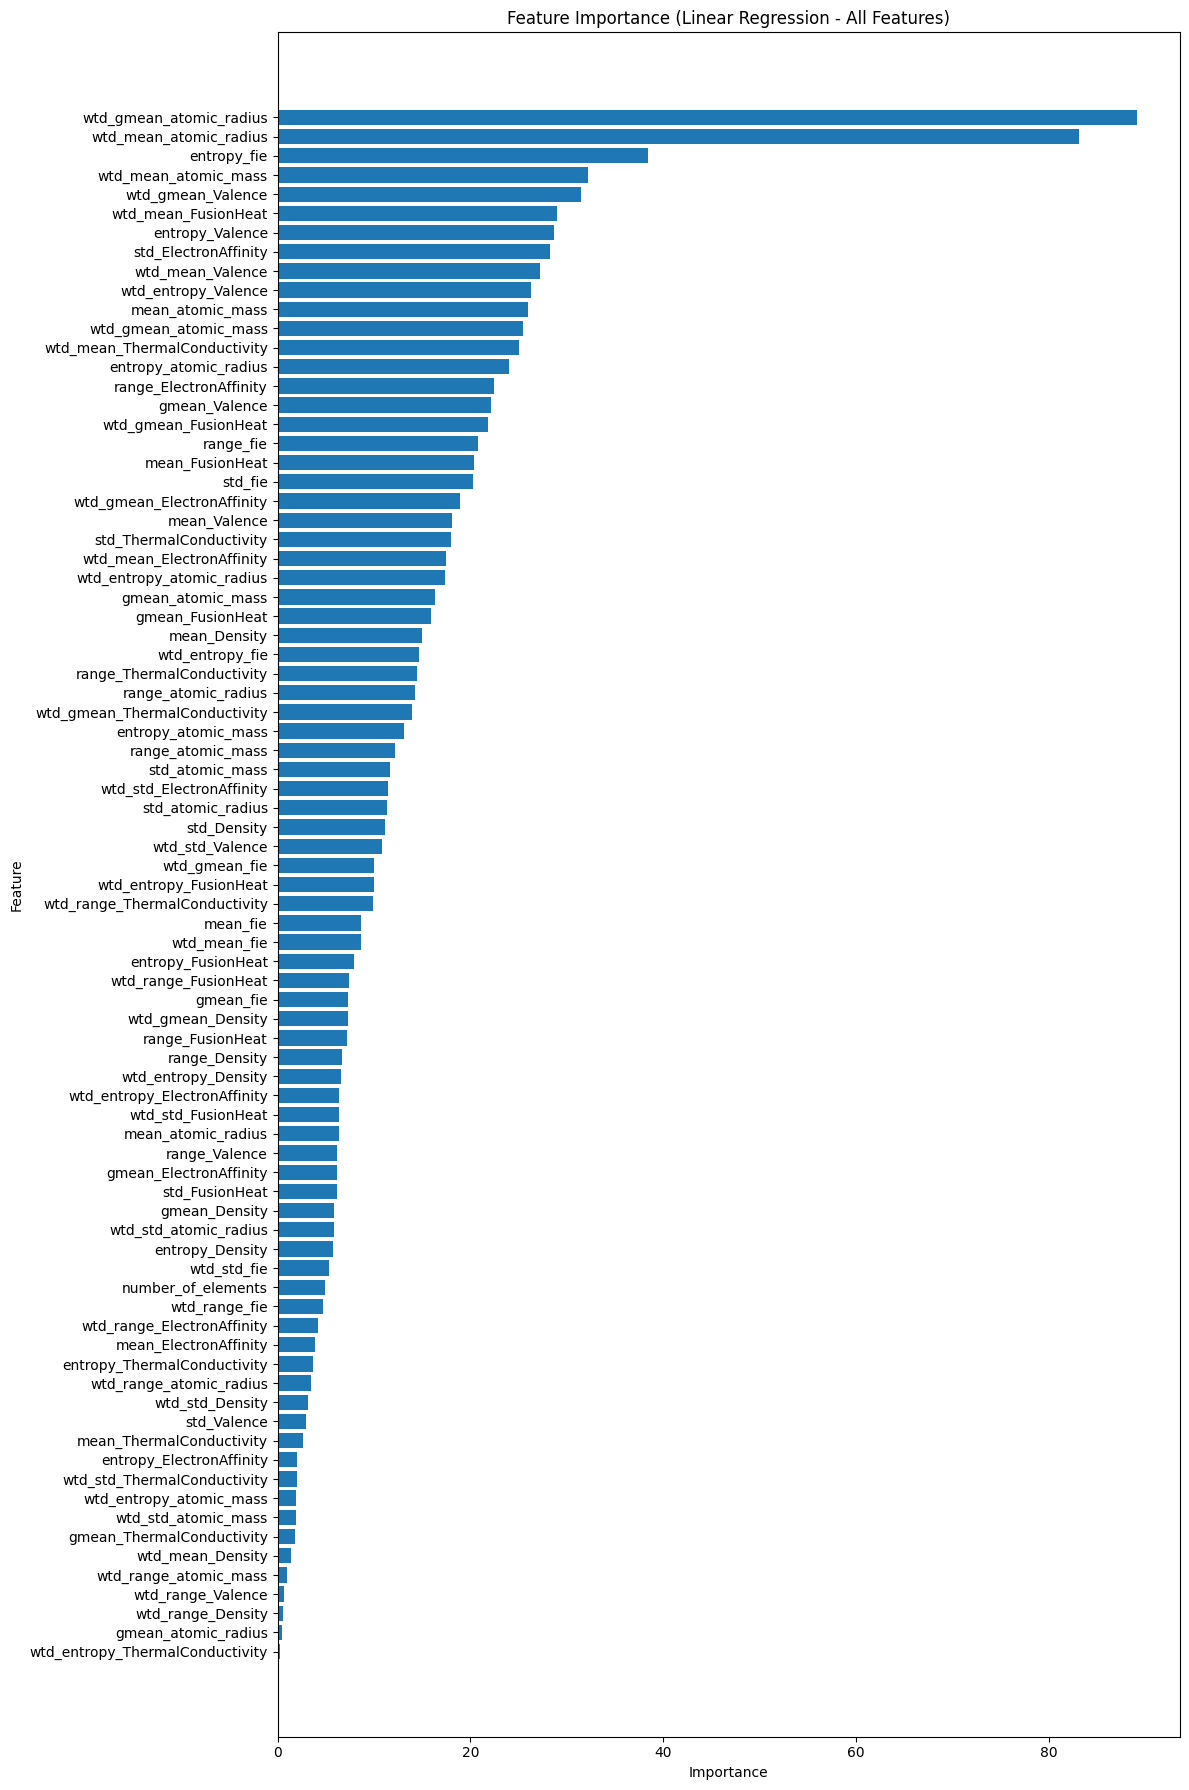



TOP 10 IMPORTANT FEATURES
                    Feature  Coefficient  Absolute_Coefficient
24  wtd_gmean_atomic_radius   -89.139308             89.139308
22   wtd_mean_atomic_radius    83.170114             83.170114
15              entropy_fie   -38.405674             38.405674
2      wtd_mean_atomic_mass   -32.204229             32.204229
74        wtd_gmean_Valence   -31.421406             31.421406
52      wtd_mean_FusionHeat   -28.982422             28.982422
75          entropy_Valence    28.620624             28.620624
49     std_ElectronAffinity    28.251291             28.251291
72         wtd_mean_Valence    27.257138             27.257138
76      wtd_entropy_Valence   -26.292397             26.292397


In [2]:
# ============================================================
# SUPERCONDUCTOR CRITICAL TEMPERATURE PREDICTION
# LINEAR REGRESSION USING ALL FEATURES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv("train.csv")

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("Shape:", df.shape)

# ============================================================
# 2. INPUT AND OUTPUT
# ============================================================

target = "critical_temp"

X = df.drop(columns=[target])
y = df[target]

print("\nTotal Features:", X.shape[1])

# ============================================================
# 3. CHECK MISSING VALUES
# ============================================================

print("\nMissing Values:")
print(df.isnull().sum().sum())

# ============================================================
# 4. HANDLE MISSING VALUES
# ============================================================

X = X.fillna(X.median())
y = y.fillna(y.median())

# ============================================================
# 5. CORRELATION MATRIX
# ============================================================

corr_matrix = df.corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of All Features")
plt.show()

# ============================================================
# 6. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ============================================================
# 7. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# ============================================================
# 8. LINEAR REGRESSION MODEL
# ============================================================

model = LinearRegression()

model.fit(X_train_scaled, y_train)

# ============================================================
# 9. PREDICTIONS
# ============================================================

y_pred = model.predict(X_test_scaled)

# ============================================================
# 10. EVALUATION METRICS
# ============================================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

mape = mean_absolute_percentage_error(
    y_test,
    y_pred
)

n = len(y_test)
p = X_test.shape[1]

adj_r2 = 1 - (
    ((1 - r2) * (n - 1))
    /
    (n - p - 1)
)

print("\n")
print("=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print(f"MAE           : {mae:.4f}")
print(f"MSE           : {mse:.4f}")
print(f"RMSE          : {rmse:.4f}")
print(f"R2 Score      : {r2:.4f}")
print(f"Adjusted R2   : {adj_r2:.4f}")
print(f"MAPE          : {mape:.4f}")

# ============================================================
# 11. ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.xlabel("Actual Critical Temperature")
plt.ylabel("Predicted Critical Temperature")
plt.title("Actual vs Predicted")

plt.show()

# ============================================================
# 12. RESIDUAL PLOT
# ============================================================

residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color='red'
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

# ============================================================
# 13. FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

importance["Absolute_Coefficient"] = (
    importance["Coefficient"].abs()
)

importance = importance.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print("\n")
print("=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)

print(importance)

# ============================================================
# 14. FEATURE IMPORTANCE GRAPH
# ============================================================

plt.figure(figsize=(12, 18))

plt.barh(
    importance["Feature"],
    importance["Absolute_Coefficient"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance (Linear Regression - All Features)")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

# ============================================================
# 15. TOP 10 MOST IMPORTANT FEATURES
# ============================================================

print("\n")
print("=" * 60)
print("TOP 10 IMPORTANT FEATURES")
print("=" * 60)

print(importance.head(10))